In [17]:
import jax
import jax.numpy as jnp
import numpy as np
import liesel.model as lsl
import liesel.goose as gs
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

from tensorflow_probability.substrates.jax.experimental import distributions as tfde
from tensorflow_probability.python.internal.backend.jax.compat import v2 as tf
import tensorflow_probability.substrates.jax.distributions as tfd
import tensorflow_probability.substrates.jax.bijectors as tfb

In [18]:
# Factory Functions to handle validate_args consistently

def make_wishart(df, scale_tril):
    """Factory that keeps validate_args strictly as a Python constant."""
    return tfd.WishartTriL(
        df=df, 
        scale_tril=scale_tril, 
        input_output_cholesky=True, 
        validate_args=False
    )

def make_mvn_precision(loc, precision_factor):
    """Factory for Precision-based MVN."""
    return tfde.MultivariateNormalPrecisionFactorLinearOperator(
        loc=loc,
        precision_factor=tf.linalg.LinearOperatorLowerTriangular(precision_factor),
        validate_args=False
    )

In [19]:
def run_hmnl_model(data, num_chains=4, warmup_duration=2000, posterior_duration=10000, seed=123):
    """
    Builds and samples from a Hierarchical Multinomial Logit (HMNL) model.
    Automatically detects if demographic variables (Z) are present in the data.
    
    Parameters:
    - data: dict containing 'X', 'y', 'unit_idx', and optionally 'Z'
    - num_chains: int, number of MCMC chains
    - warmup_duration: int, number of warmup steps
    - posterior_duration: int, number of posterior samples
    - seed: int, random seed
    
    Returns:
    - results: Liesel results object
    - samples: dict of posterior samples
    - model: the constructed Liesel model
    """
    
    # Extract dimensions
    X_data = data["X"]
    y_data = data["y"]
    idx_data = data["unit_idx"]
    
    n_units = len(jnp.unique(idx_data))
    k_dim = X_data.shape[2]
    
    has_demographics = "Z" in data and data["Z"] is not None

    print(f"Building Model: {n_units} units, {k_dim} parameters.")
    print(f"Demographics (Z matrix) included: {has_demographics}")

    # Constants
    nu_val = float(k_dim + 3)
    V_inv_val = jnp.linalg.inv(nu_val * jnp.eye(k_dim))
    Vinv_chol_val = jnp.linalg.cholesky(V_inv_val)
    A_val = 0.01

    # 1. Precision Matrix (Shared for both setups)
    sigma_inv_chol = lsl.Var.new_param(
        value=jnp.eye(k_dim),
        distribution=lsl.Dist(make_wishart, df=nu_val, scale_tril=Vinv_chol_val),
        name="sigma_inv_chol"
    )

    sigma_inv_chol_latent = sigma_inv_chol.transform(
        tfb.FillScaleTriL(diag_bijector=tfb.Exp()), 
        name="sigma_inv_chol_latent"
    )

    # List to hold kernels
    kernels = [gs.NUTSKernel(["sigma_inv_chol_latent"], mm_diag=False)]

    # 2. Mean Structure & Unit-Level Parameters
    if has_demographics:
        Z_data = data["Z"]
        n_z = Z_data.shape[1]
        
        # MRM Prior for Delta
        delta_prec_factor = lsl.Var.new_calc(
            lambda L: jnp.sqrt(A_val) * L, 
            L=sigma_inv_chol, 
            name="delta_prec_factor"
        )

        Delta = lsl.Var.new_param(
            value=jnp.zeros((n_z, k_dim)),
            distribution=lsl.Dist(make_mvn_precision, loc=jnp.zeros(k_dim), precision_factor=delta_prec_factor),
            name="Delta"
        )

        # Calculate Beta Mean: B = Z * Delta
        Z_var = lsl.Var.new_obs(Z_data, name="Z_obs")
        beta_mean = lsl.Var.new_calc(
            lambda Z, D: jnp.dot(Z, D),
            Z=Z_var,
            D=Delta,
            name="beta_mean"
        )
        
        beta_loc = beta_mean
        kernels.append(gs.NUTSKernel(["Delta"]))
        
    else:
        # Standard Global Mean (mu)
        mu_prec_factor = lsl.Var.new_calc(
            lambda L: jnp.sqrt(A_val) * L, 
            L=sigma_inv_chol, 
            name="mu_prec_factor"
        )

        mu = lsl.Var.new_param(
            value=jnp.zeros(k_dim),
            distribution=lsl.Dist(make_mvn_precision, loc=jnp.zeros(k_dim), precision_factor=mu_prec_factor),
            name="mu"
        )
        
        beta_loc = mu
        kernels.append(gs.NUTSKernel(["mu"]))

    # Unit-level parameters (beta_i)
    beta_i = lsl.Var.new_param(
        value=jnp.zeros((n_units, k_dim)),
        distribution=lsl.Dist(make_mvn_precision, loc=beta_loc, precision_factor=sigma_inv_chol),
        name="beta_i"
    )
    kernels.append(gs.NUTSKernel(["beta_i"]))

    # 3. Likelihood & Observation Model
    X_var = lsl.Var.new_obs(X_data, name="X_obs")
    idx_var = lsl.Var.new_obs(idx_data, name="idx_obs")

    beta_expanded = lsl.Var.new_calc(
        lambda b, idx: b[idx], 
        b=beta_i, 
        idx=idx_var, 
        name="beta_expanded"
    )

    logits = lsl.Var.new_calc(
        lambda x, b: jnp.einsum("nij,nj->ni", x, b), 
        x=X_var, 
        b=beta_expanded, 
        name="logits"
    )

    y_var = lsl.Var.new_obs(
        y_data, 
        distribution=lsl.Dist(tfd.Categorical, logits=logits), 
        name="y"
    )

    model = lsl.Model([y_var])

    # ====================
    # INFERENCE
    # ====================
    eb = gs.EngineBuilder(seed=seed, num_chains=num_chains)
    eb.set_model(gs.LieselInterface(model))
    eb.set_initial_values(model.state)

    for kernel in kernels:
        eb.add_kernel(kernel)

    eb.set_duration(warmup_duration=warmup_duration, posterior_duration=posterior_duration)

    print("Starting Sampling...")
    engine = eb.build()
    engine.sample_all_epochs()

    results = engine.get_results()
    samples = results.get_posterior_samples()

    print("Sampling Complete.")
    
    return results, samples, model

# ====================
# USAGE EXAMPLE
# ====================
# For data WITH demographics:
# results, samples, model = run_hmnl_model(data_with_Z)

# For data WITHOUT demographics:
# results, samples, model = run_hmnl_model(data_without_Z)

In [20]:
# Data Simulation

def simulate_data(seed=42):
    key = jax.random.PRNGKey(seed)
    k1, k2, k3 = jax.random.split(key, 3)
    
    n_units, n_obs_small, n_obs_large, n_alts, n_params = 100, 5, 50, 5, 5 
    counts = jnp.array([n_obs_small] * 50 + [n_obs_large] * 50)
    unit_idx = jnp.repeat(jnp.arange(n_units), counts)
    
    true_mu = jnp.array([1.0, -1.0, 0.0, 0.0, -3.0])
    true_Sigma = 3.0 * jnp.eye(n_params)
    true_Sigma = true_Sigma.at[3, 4].set(1.5)
    true_Sigma = true_Sigma.at[4, 3].set(1.5)
    
    beta_dist = tfd.MultivariateNormalFullCovariance(loc=true_mu, covariance_matrix=true_Sigma)
    betas = beta_dist.sample(seed=k1, sample_shape=(n_units,))
    
    X_list, y_list = [], []
    for i in range(n_units):
        n_i, beta_i = counts[i], betas[i]
        k2, sk = jax.random.split(k2)
        price = jax.random.uniform(sk, shape=(n_i, n_alts), minval=-1.5, maxval=0.0)
        
        D = jnp.zeros((n_i, n_alts, n_params))
        for a in range(4): D = D.at[:, a, a].set(1.0)
        D = D.at[:, :, 4].set(price)
        
        logits = jnp.einsum('ijk,k->ij', D, beta_i)
        k3, sk = jax.random.split(k3)
        choices = tfd.Categorical(logits=logits).sample(seed=sk)
        
        X_list.append(D)
        y_list.append(choices)
        
    return {
        "X": jnp.concatenate(X_list, axis=0),
        "y": jnp.concatenate(y_list, axis=0),
        "betas": betas,
        "unit_idx": unit_idx,
        "true_mu": true_mu,
        "true_Sigma": true_Sigma
    }

# Simulate Data for 100 decision makers
data = simulate_data()
k_dim = 5
n_units = 100

In [21]:
# 1. Run the Model
# ==========================================


# Simulate Data for 100 decision makers
data = simulate_data()

# Execute the model (will automatically use 'mu' since 'Z' is absent)
results, samples, model = run_hmnl_model(
    data=data,
    num_chains=1,
    warmup_duration=2000,
    posterior_duration=10000,
    seed=123
)

Building Model: 100 units, 5 parameters.
Demographics (Z matrix) included: False


c:\Users\ThinkPad\Desktop\Repositories\BDCM\liesel_project\.venv\Lib\site-packages\jax\_src\numpy\array_methods.py:122: UserWarning: Explicitly requested dtype float64 requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/jax-ml/jax#current-gotchas for more.
  return lax_numpy.astype(self, dtype, copy=copy, device=device)
liesel.goose.builder - WARNING - No jitter functions provided. The initial values won't be jittered
liesel.goose.engine - INFO - Initializing kernels...


Starting Sampling...


liesel.goose.engine - INFO - Done
liesel.goose.engine - INFO - Starting epoch: FAST_ADAPTATION, 75 transitions, 25 jitted together
100%|██████████████████████████████████████████| 3/3 [00:20<00:00,  6.94s/chunk]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 5 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 1 / 75 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 2 / 75 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - INFO - Starting epoch: SLOW_ADAPTATION, 25 transitions, 25 jitted together
100%|█████████████████████████████████████████| 1/1 [00:00<00:00, 378.75chunk/s]
liesel.goose.engine - WARNING - Errors per chain for kernel_00: 1 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_01: 2 / 25 transitions
liesel.goose.engine - WARNING - Errors per chain for kernel_02: 1 / 25 transitions
liesel.goose.engine - INFO - Finished epoch
liesel.goose.engine - IN

Sampling Complete.


In [22]:
# 2. Extract Results
# ==========================================
k_dim = data["X"].shape[2]
n_units = len(np.unique(data["unit_idx"]))

# Extract latent sigma samples for covariance calculation
latent_samples = samples["sigma_inv_chol_latent"]
n_chains, n_draws, n_latent = latent_samples.shape

# Setup bijector mapping to reconstruct Covariance
bijector = tfb.FillScaleTriL(diag_bijector=tfb.Exp())
def latent_to_sigma(latent_vec):
    L = bijector.forward(latent_vec)
    precision_mat = L @ L.T
    return jnp.linalg.inv(precision_mat)

v_latent_to_sigma = jax.vmap(jax.vmap(latent_to_sigma))
sigma_samples = v_latent_to_sigma(latent_samples)

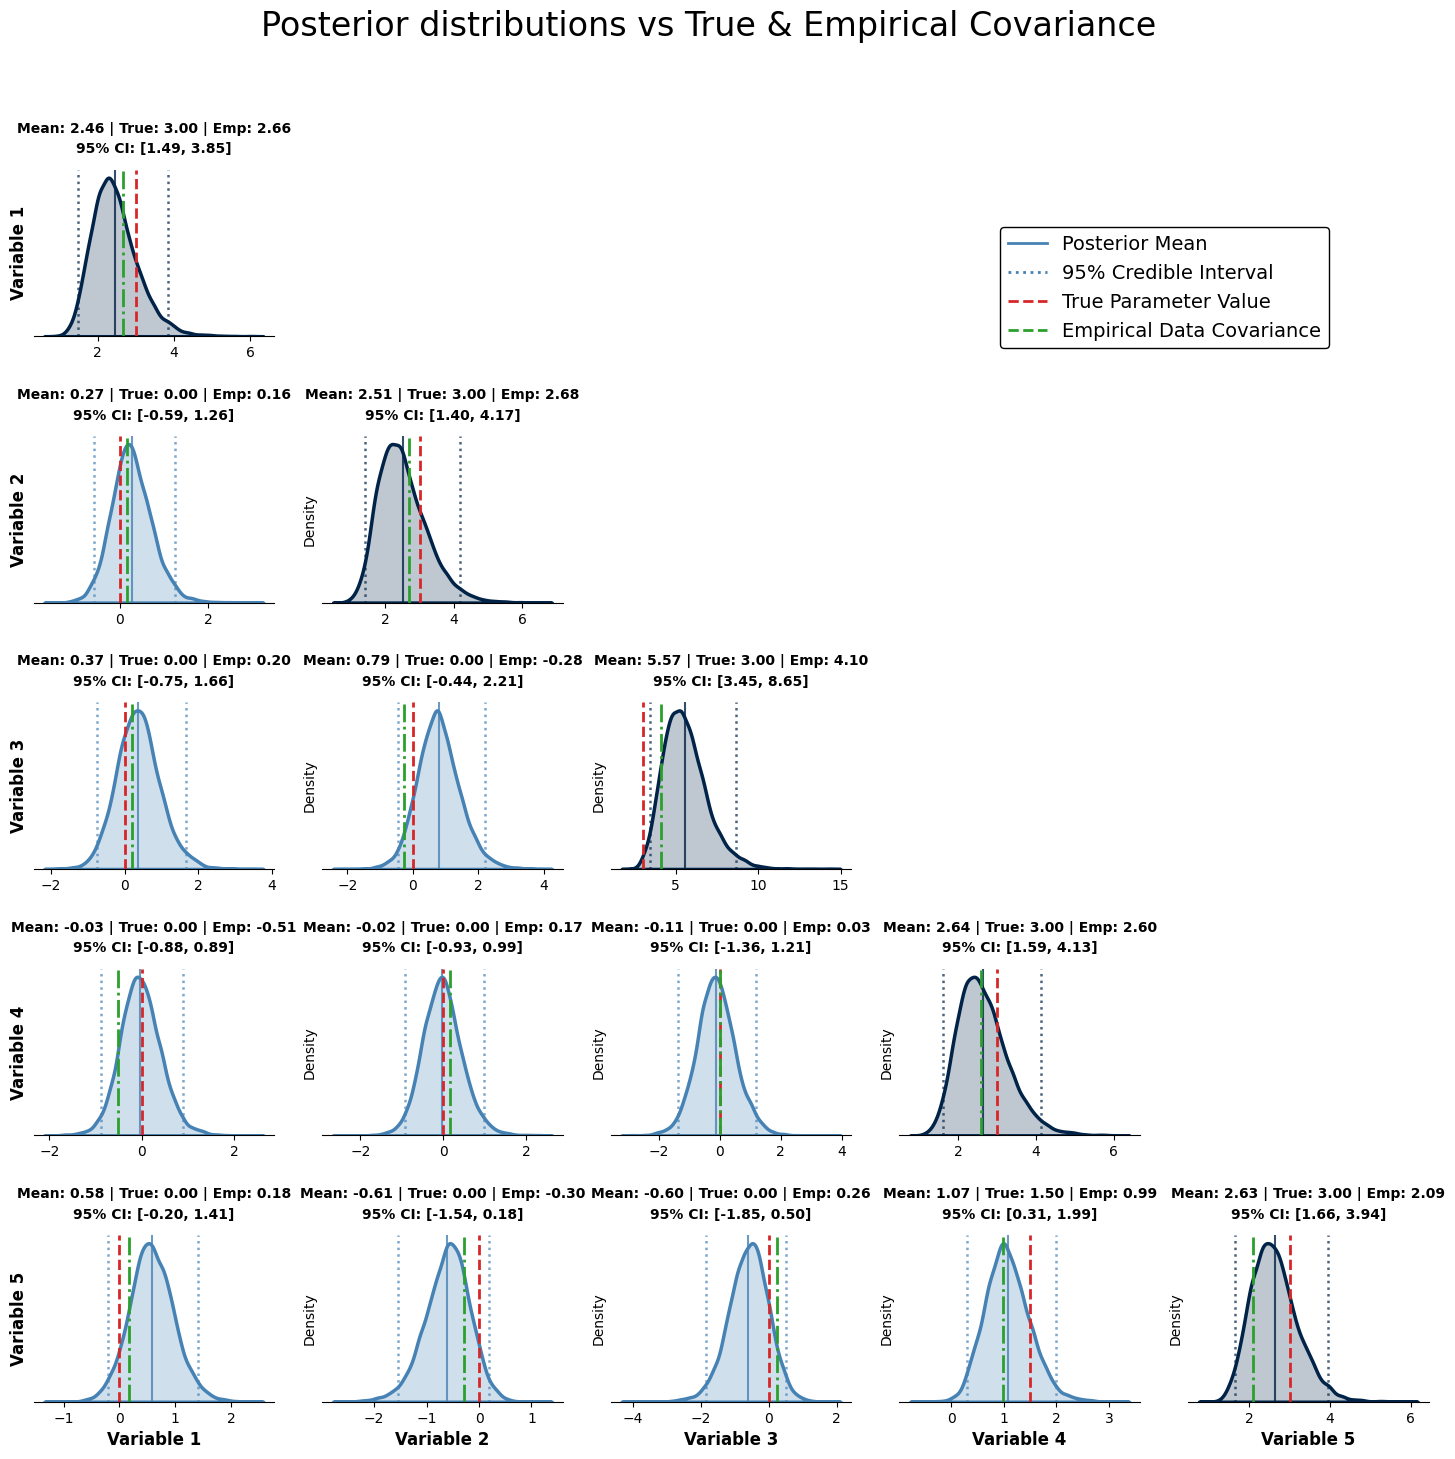

In [23]:
def plot_final_covariance_complete(samples, true_matrix=None, empirical_matrix=None):
    n_dim = samples.shape[-1]
    
    # Create the figure and axes
    fig, axes = plt.subplots(n_dim, n_dim, figsize=(18, 16))
    
    flattened_samples = samples.reshape(-1, n_dim, n_dim)
    
    # Color Palette
    diag_color      = "#002347"  
    off_diag_color  = "#4682B4"  
    true_val_color  = "#D62728"  
    emp_val_color   = "#2CA02C"  

    # Loop through the grid
    for i in range(n_dim):
        for j in range(n_dim):
            ax = axes[i, j]
            
            # Lower Triangular Logic
            if j > i:
                ax.axis('off') 
                continue
            
            data_vec = flattened_samples[:, i, j]
            is_diag = (i == j)
            current_color = diag_color if is_diag else off_diag_color
            
            # Stats Calculation
            post_mean = np.mean(data_vec)
            ci_low, ci_high = np.percentile(data_vec, [2.5, 97.5])
            
            # Plot KDE
            sns.kdeplot(data_vec, ax=ax, fill=True, color=current_color, alpha=0.25, lw=2.5)
            
            # Reference Lines
            ax.axvline(post_mean, color=current_color, linestyle="-", lw=1.5, alpha=0.8)
            ax.axvline(ci_low, color=current_color, linestyle=":", lw=1.8, alpha=0.7)
            ax.axvline(ci_high, color=current_color, linestyle=":", lw=1.8, alpha=0.7)
            
            title_parts = [f"Mean: {post_mean:.2f}"]
            
            if true_matrix is not None:
                true_val = true_matrix[i, j]
                ax.axvline(true_val, color=true_val_color, linestyle="--", lw=2)
                title_parts.append(f"True: {true_val:.2f}")
            
            if empirical_matrix is not None:
                emp_val = empirical_matrix[i, j]
                ax.axvline(emp_val, color=emp_val_color, linestyle="-.", lw=2)
                title_parts.append(f"Emp: {emp_val:.2f}")

            # Textual Labels
            stats_str = " | ".join(title_parts)
            title_str = (
                f"{stats_str}\n"
                f"95% CI: [{ci_low:.2f}, {ci_high:.2f}]"
            )
            ax.set_title(title_str, fontsize=10, pad=12, linespacing=1.6, fontweight='bold')

            # Aesthetic Polish
            ax.set_yticks([])
            sns.despine(ax=ax, left=True)
            
            if i == n_dim - 1:
                ax.set_xlabel(f"Variable {j+1}", fontsize=12, fontweight='bold')
            if j == 0:
                ax.set_ylabel(f"Variable {i+1}", fontsize=12, fontweight='bold')

    # --- NEW: FIGURE-LEVEL FLOATING LEGEND ---
    legend_elements = [
        Line2D([0], [0], color=off_diag_color, linestyle='-',  lw=2, label='Posterior Mean'),
        Line2D([0], [0], color=off_diag_color, linestyle=':',  lw=2, label='95% Credible Interval'),
        Line2D([0], [0], color=true_val_color, linestyle='--', lw=2, label='True Parameter Value'),
        Line2D([0], [0], color=emp_val_color,  linestyle='--', lw=2, label='Empirical Data Covariance')
    ]
    
    # We use fig.legend instead of ax.legend
    fig.legend(
        handles=legend_elements, 
        loc='upper right',           # Anchor point on the legend box
        bbox_to_anchor=(0.85, 0.85), # (x, y) coordinates for the anchor relative to the whole figure (0 to 1)
        fontsize=14, 
        frameon=True,         
        edgecolor='black',    
        framealpha=1,         
        fancybox=True         
    )

    plt.suptitle("Posterior distributions vs True & Empirical Covariance", 
                 fontsize=24, y=0.98, fontweight='light')
    
    plt.subplots_adjust(hspace=0.6, wspace=0.2)
    plt.show()

# 3. Analytics: Covariance Matrix
# ==========================================
empirical_sigma = jnp.cov(data["betas"], rowvar=False)

# Re-using the plot function defined in your previous notebooks
plot_final_covariance_complete(sigma_samples, data["true_Sigma"], empirical_sigma)


=== Mu (Global Population Mean) Summary ===
Shape: (5,)

Posterior Means:
 [ 0.99000007 -0.89300007  0.36400002  0.13000001 -3.009     ]

True Means:
 [ 1.        -1.         0.         0.        -3.0000002]

Posterior Std Dev:
 [0.19900002 0.238      0.293      0.215      0.21100001]

=== Unit-Level Parameter Recovery (Beta_i) ===


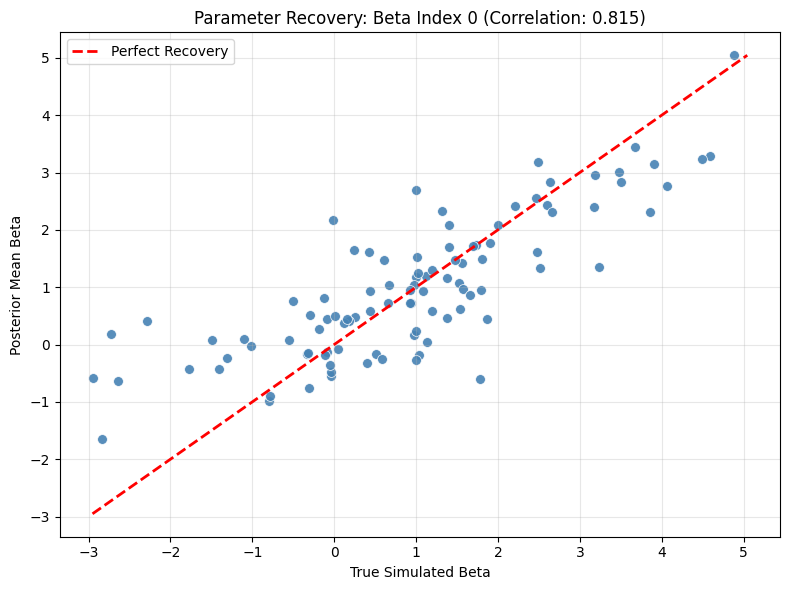

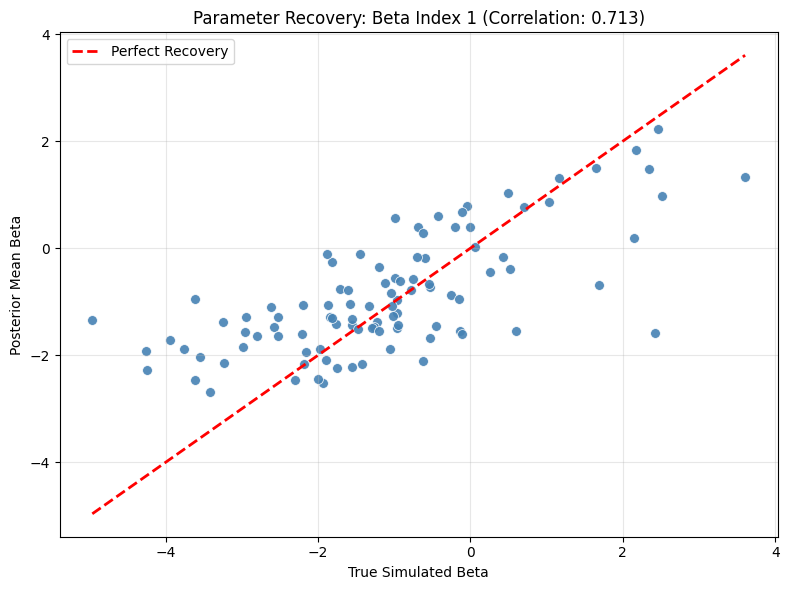

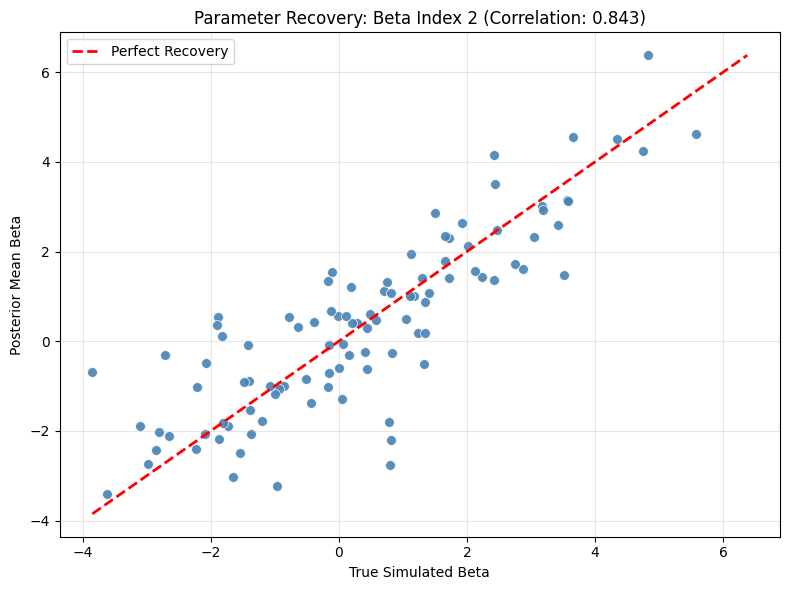

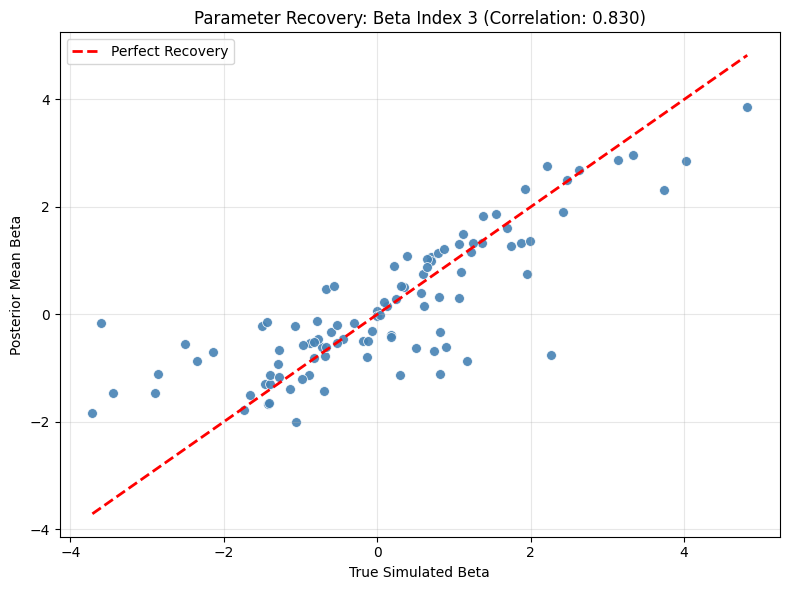

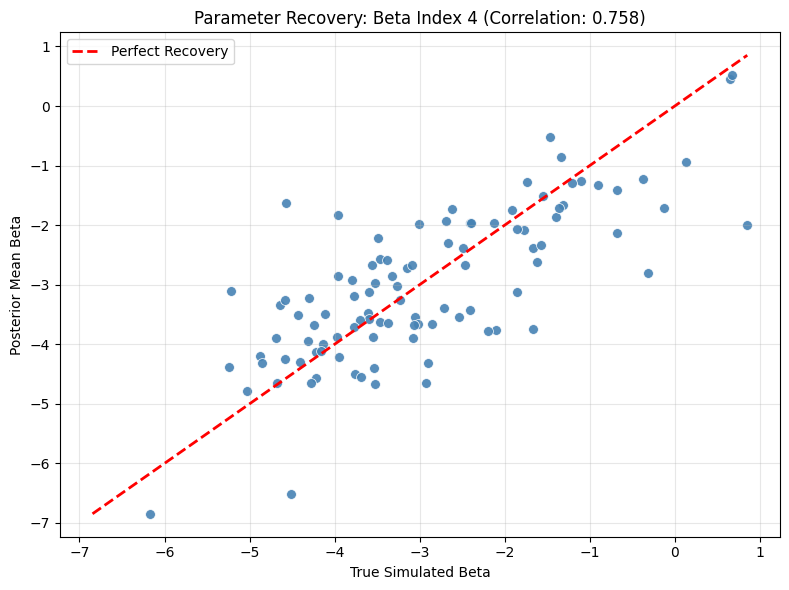


=== Combined Posterior Distributions (All Units Pooled) ===


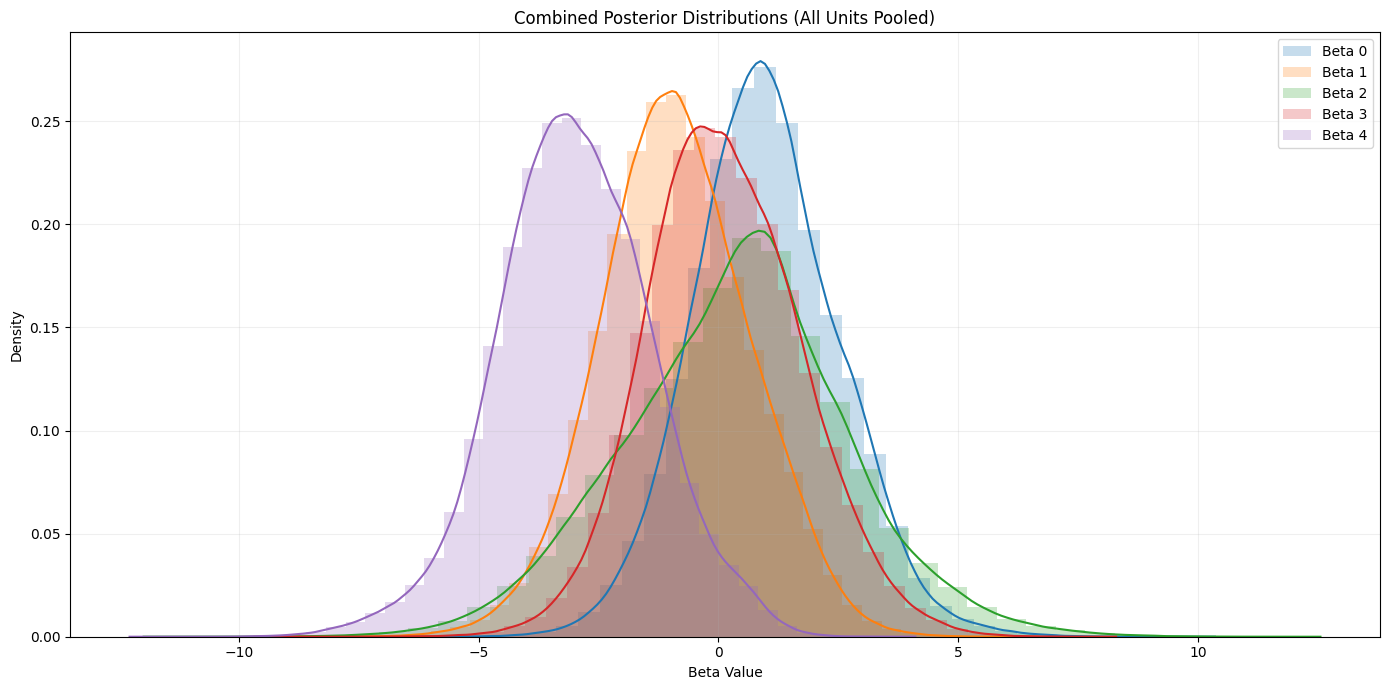

In [24]:


# 4. Analytics: Global Mu
# ==========================================
print("\n=== Mu (Global Population Mean) Summary ===")
mu_posterior_means = jnp.mean(samples["mu"], axis=(0, 1))
mu_posterior_stds = jnp.std(samples["mu"], axis=(0, 1))

print(f"Shape: {mu_posterior_means.shape}")
print("\nPosterior Means:\n", np.round(mu_posterior_means, 3))
print("\nTrue Means:\n", np.round(data["true_mu"], 3))
print("\nPosterior Std Dev:\n", np.round(mu_posterior_stds, 3))

# 5. Analytics: Unit-Level Parameters (Beta_i) Recovery
# ==========================================
print("\n=== Unit-Level Parameter Recovery (Beta_i) ===")
beta_posterior_means = jnp.mean(samples["beta_i"], axis=(0, 1)) 
beta_posterior_stds = jnp.std(samples["beta_i"], axis=(0, 1)) 

for param_idx in range(k_dim):
    plt.figure(figsize=(8, 6))
    
    # Note: Using data["betas"] here to match your simulation output
    sns.scatterplot(
        x=data["betas"][:, param_idx], 
        y=beta_posterior_means[:, param_idx], 
        alpha=0.9, 
        s=50,
        color='steelblue'
    )
    
    # Calculate bounds for the identity line
    min_val = min(data["betas"][:, param_idx].min(), beta_posterior_means[:, param_idx].min())
    max_val = max(data["betas"][:, param_idx].max(), beta_posterior_means[:, param_idx].max())
    
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label="Perfect Recovery")
    
    # Calculate correlation
    corr = np.corrcoef(data["betas"][:, param_idx], beta_posterior_means[:, param_idx])[0, 1]
    
    plt.xlabel("True Simulated Beta")
    plt.ylabel("Posterior Mean Beta")
    plt.title(f"Parameter Recovery: Beta Index {param_idx} (Correlation: {corr:.3f})")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# 6. Analytics: Posterior Distributions 
# ==========================================
print("\n=== Combined Posterior Distributions (All Units Pooled) ===")
plt.figure(figsize=(14, 7))
for b in range(k_dim):
    arr = samples["beta_i"][..., b].reshape(-1) 
    sns.histplot(arr, bins=40, kde=True, stat="density", alpha=0.25, linewidth=0, label=f"Beta {b}")
plt.title("Combined Posterior Distributions (All Units Pooled)")
plt.xlabel("Beta Value")
plt.ylabel("Density")
plt.grid(True, alpha=0.2)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()